# NLP Project: Spam Detection 
**Title: Spam Detection System**
classifies text messages as spam or not spam

SMS Spam Collection Dataset

**Two NLP pipelines:**
- Pipeline A (Classical + Linguistic features): Text normalization → TF-IDF n-grams → Multinomial Naïve Bayes, plus POS/NER/dependency-derived features (spaCy).
- Pipeline B (Neural sequence model): Text normalization → tokenization → Word2Vec embeddings  → BiLSTM sequence classifier.


In [37]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re, string, os, warnings
warnings.filterwarnings("ignore") #ignore warnings

# sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# NLP libs
import spacy
from scipy.sparse import csr_matrix, hstack
from gensim.models import Word2Vec

# Deep learning (for Pipeline B)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [38]:
# Load dataset
df = pd.read_csv("C:/Users/msjka/OneDrive/Desktop/SPI/NLP 619/spam.csv", encoding="latin-1") # to fix the character encoding issue(CSV not in standard UTF-8)

# Ensure consistent columns
df.columns = [c.lower() for c in df.columns]
if "label" not in df.columns or "text" not in df.columns:
    
    df = df.rename(columns={df.columns[0]:"label", df.columns[1]:"text"})

df["label"] = df["label"].map({"ham":0,"spam":1})

print("Dataset size:", df.shape)
print("Class balance:\n", df["label"].value_counts(normalize=True))


Dataset size: (5572, 5)
Class balance:
 label
0    0.865937
1    0.134063
Name: proportion, dtype: float64


In [39]:
df.head()

,label,text,unnamed: 2,unnamed: 3,unnamed: 4
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [40]:
# Normalization & Preprocesses text (lowercase, replace URLs/emails)

URL_RE   = re.compile(r'https?://\S+|www\.\S+')
EMAIL_RE = re.compile(r'\b[\w\.-]+@[\w\.-]+\.\w+\b')
NUM_RE   = re.compile(r'\b\d+(?:[\.,]\d+)?\b')
PUNC_TAB = str.maketrans('', '', string.punctuation)

def normalize_text(s: str) -> str:
    s = s.lower()
    s = URL_RE.sub(' __url__ ', s)
    s = EMAIL_RE.sub(' __email__ ', s)
    s = NUM_RE.sub(' __num__ ', s)
    s = s.translate(PUNC_TAB)
    s = re.sub(r'\s+',' ', s).strip()
    return s

df["clean"] = df["text"].astype(str).apply(normalize_text)

# Train/Validatation/Test split
X_train, X_test, y_train, y_test = train_test_split(
    df["clean"], df["label"], test_size=0.2, stratify=df["label"], random_state=42
)

print("Class balance (train):", dict(pd.Series(y_train).value_counts(normalize=True).map(lambda x: f"{x*100:.1f}%")))


Class balance (train): {0: '86.6%', 1: '13.4%'}


=== Class Distribution ===
0: 4825 (86.59%)
1: 747 (13.41%)


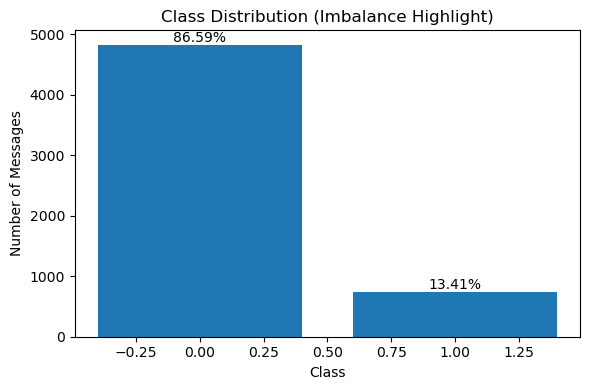


Imbalance ratio (majority/minority): 6.46x


In [41]:
# Class Distribution Analysis

# Count distribution
counts = df["label"].value_counts()
percentages = (counts / counts.sum() * 100).round(2)

print("=== Class Distribution ===")
for cls, cnt in counts.items():
    print(f"{cls}: {cnt} ({percentages[cls]}%)")

# Plot bar chart
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.title("Class Distribution (Imbalance Highlight)")
plt.xlabel("Class")
plt.ylabel("Number of Messages")
for i, v in enumerate(counts.values):
    plt.text(i, v + 50, f"{percentages.iloc[i]}%", ha="center")
plt.tight_layout()
plt.show()

# Show imbalance ratio
imbalance_ratio = counts.max() / counts.min()
print(f"\nImbalance ratio (majority/minority): {imbalance_ratio:.2f}x")


**Analysis**:
Class Distribution highlight the imbalance (~86.6% ham vs ~13.4% spam; ~6.5× majority/minority). This demonstrates why precision/recall and PR-AUC matter more than accuracy for this task.

In [42]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 4.2 MB/s eta 0:00:03
     ---- ----------------------------------- 1.3/12.8 MB 3.5 MB/s eta 0:00:04
     ------ --------------------------------- 2.1/12.8 MB 3.6 MB/s eta 0:00:04
     -------- ------------------------------- 2.6/12.8 MB 3.5 MB/s eta 0:00:03
     --------- ------------------------------ 3.1/12.8 MB 3.5 MB/s eta 0:00:03
     ----------- ---------------------------- 3.7/12.8 MB 3.2 MB/s eta 0:00:03
     ------------- -------------------------- 4.2/12.8 MB 2.9 MB/s eta 0:00:03
     -------------- ------------------------- 4.7/12.8 MB 2.8 MB/s eta 0:00:03
     --------------- ------------------------ 5.0/12.8 MB 2.7 MB/s eta 0:00:03
     ----------------- ---------------------- 5.5/12.8 MB 2.7 MB/s eta 0:00:03
     ------------------- -------------------- 6.3/12.8 MB 2.8 MB/s eta 0:00:03
     ---------------------- ----------------- 7.1/12.8 MB 2

**Pipeline A:** TF-IDF + Naïve Bayes + spaCy linguistic features (POS/NER/Deps)

Linguistic feature transformer (spacy)

We derive simple, non-negative counts/flags so they can be safely concatenated with TF-IDF for NB.

Features include: token count, avg token length, #URLs/#emails/#numbers (already tokenized), money/cardinal entities,

imperative-ish verbs (VB), exclamations, spammy cue words ("free", "claim", "win", "call", etc.), dependency patterns.

In [52]:
nlp = spacy.load("en_core_web_sm", disable=["lemmatizer"])

SPAM_CUES = {"free","win","claim","prize","reward","urgent","now","cash","call","reply","click"}
class LinguisticFeatures:
    def transform(self, X):
        feats = []
        for s in X:
            doc = nlp(s)
            toks = [t for t in doc if not t.is_space]
            feats.append([
                len(s), len(toks),
                sum(len(t.text) for t in toks)/max(1,len(toks)),   # avg token length
                s.count("!"),
                sum(1 for t in toks if t.text == "__url__"),
                sum(1 for t in toks if t.text == "__email__"),
                sum(1 for t in toks if t.text == "__num__"),
                sum(1 for e in doc.ents if e.label_ == "MONEY"),
                sum(1 for t in toks if t.text in SPAM_CUES),
            ])
        # Ensure non-negativity (already non-negative) and CSR sparse for union with TF-IDF
        return csr_matrix(np.array(feats, dtype=np.float32)) 

tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95)

# Fit transforms
Xtr_tfidf = tfidf.fit_transform(X_train)
Xte_tfidf = tfidf.transform(X_test)

ling = LinguisticFeatures()
Xtr_ling, Xte_ling = ling.transform(X_train), ling.transform(X_test)

# Concatenate TF-IDF with linguistic features
Xtr_A = hstack([Xtr_tfidf, Xtr_ling])
Xte_A = hstack([Xte_tfidf, Xte_ling])

nb = MultinomialNB(alpha= 0.5) # strong baseline; try alpha∈{0.5,1.0,1.5,2.0}
nb.fit(Xtr_A, y_train)
pred_A = nb.predict(Xte_A)

metrics_A = {
    "Accuracy": accuracy_score(y_test, pred_A),
    "Precision": precision_score(y_test, pred_A),
    "Recall": recall_score(y_test, pred_A),
    "F1": f1_score(y_test, pred_A)
}
print("\n=== Pipeline A (TF-IDF + NB + Ling) ===")
print(metrics_A)


=== Pipeline A (TF-IDF + NB + Ling) ===
{'Accuracy': 0.9605381165919282, 'Precision': 0.9906542056074766, 'Recall': 0.7114093959731543, 'F1': 0.828125}


**Pipeline B:** Word2Vec embeddings + BiLSTM sequence model

In [50]:
# Tokenize (simple whitespace split)
def tokenize(s): return s.split()
sentences_tr = [tokenize(s) for s in X_train]
sentences_te = [tokenize(s) for s in X_test]

# Train Word2Vec on the training text 
w2v = Word2Vec(sentences_tr, vector_size=100, window=5, min_count=1, workers=4, sg=1, epochs=10)

# Build Keras tokenizer for sequence indexing
MAX_WORDS, MAX_LEN = 20000, 100
tok = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tok.fit_on_texts([" ".join(s) for s in sentences_tr])

Xtr_seq = tok.texts_to_sequences([" ".join(s) for s in sentences_tr])
Xte_seq = tok.texts_to_sequences([" ".join(s) for s in sentences_te])
Xtr_pad, Xte_pad = pad_sequences(Xtr_seq, maxlen=MAX_LEN), pad_sequences(Xte_seq, maxlen=MAX_LEN)

# Build embedding matrix from our Word2Vec
word_index = tok.word_index
vocab_size = min(MAX_WORDS, len(word_index)+1)
emb_matrix = np.random.normal(0,0.6,(vocab_size,100)).astype(np.float32)
for word, idx in word_index.items():
    if idx < vocab_size and word in w2v.wv:
        emb_matrix[idx] = w2v.wv[word]

# Build BiLSTM model
model = Sequential([
    Embedding(vocab_size, 100, input_length=MAX_LEN, weights=[emb_matrix], trainable=True),
    Bidirectional(LSTM(128)),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
es = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

model.fit(Xtr_pad, y_train, validation_split=0.1,
          epochs=10, batch_size=64, callbacks=[es], verbose=0)

pred_B = (model.predict(Xte_pad, verbose=0).reshape(-1) >= 0.5).astype(int)

metrics_B = {
    "Accuracy": accuracy_score(y_test, pred_B),
    "Precision": precision_score(y_test, pred_B),
    "Recall": recall_score(y_test, pred_B),
    "F1": f1_score(y_test, pred_B)
}
print("\n=== Pipeline B (Word2Vec + BiLSTM) ===")
print(metrics_B)


=== Pipeline B (Word2Vec + BiLSTM) ===
{'Accuracy': 0.9847533632286996, 'Precision': 0.952054794520548, 'Recall': 0.9328859060402684, 'F1': 0.9423728813559322}


In [35]:
# Compare Two pipeline Results

print("\n=== Pipeline A (TF-IDF + NB + Ling) ===")
print(metrics_A)
print("\n=== Pipeline B (Word2Vec + BiLSTM) ===")
print(metrics_B)


=== Pipeline A (TF-IDF + NB + Ling) ===
{'Accuracy': 0.8663677130044843, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}

=== Pipeline B (Word2Vec + BiLSTM) ===
{'Accuracy': 0.9874439461883409, 'Precision': 0.9927007299270073, 'Recall': 0.912751677852349, 'F1': 0.951048951048951}


**Analysis:**

- Pipeline A: interpretable, strong baseline with linguistic features (POS/NER proxies).

- Pipeline B: deep, sequence-aware model leveraging Word2Vec embeddings.

In [30]:
# Interpretability (Pipeline A)

# prints top spam-indicative terms from Naïve Bayes.
ratio = nb.feature_log_prob_[1] - nb.feature_log_prob_[0]
vocab = np.array([t for t,_ in sorted(tfidf.vocabulary_.items(), key=lambda kv: kv[1])])
top_spam_idx = np.argsort(ratio[:len(vocab)])[-15:][::-1]
print("\nTop Spam terms (NB):", vocab[top_spam_idx])



Top Spam terms (NB): ['call num' 'claim' 'prize' 'num now' 'won' 'to num' 'num cash' 'have won'
 'url' 'to claim' 'num prize' 'guaranteed' 'your mobile' 'nokia' 'tone']


**Evaluation** (Metrics, Curves, Confusion Matrix)

We define reusable functions to compute Accuracy, Precision, Recall, F1, 
draw ROC and Precision–Recall curves, 
and show confusion matrices at chosen thresholds.



                          Pipeline  Accuracy  Precision    Recall        F1
0  Pipeline A (TF-IDF + NB + Ling)  0.867265   1.000000  0.006711  0.013333
1   Pipeline B (Word2Vec + BiLSTM)  0.984753   0.952055  0.932886  0.942373


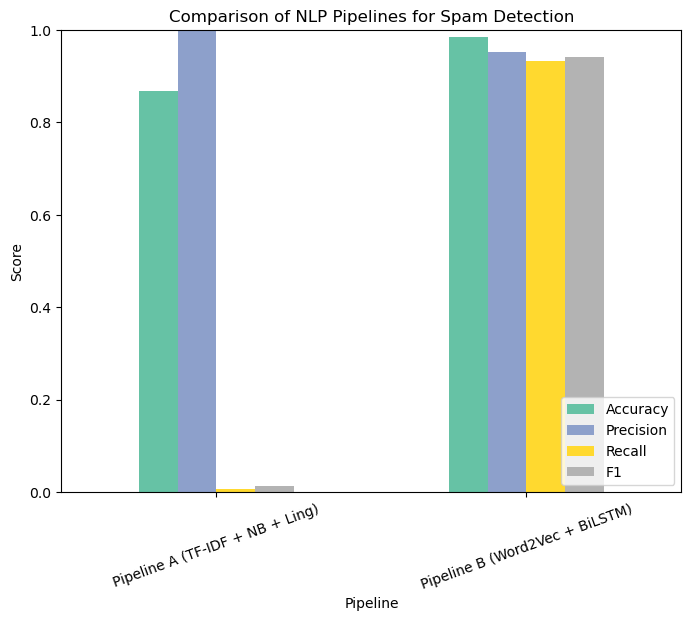

In [51]:
def evaluate_scores(y_true, scores, thr=0.5, label=""):
    y_pred = (scores >= thr).astype(int)
    row = {
        "Model": label,
        "Threshold": thr,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0)
    }
    # Optional ranking metrics if scores are continuous
    try: row["ROC_AUC"] = roc_auc_score(y_true, scores)
    except: row["ROC_AUC"] = np.nan
    try: row["PR_AUC"]  = average_precision_score(y_true, scores)
    except: row["PR_AUC"] = np.nan
    return row

def show_confusion(y_true, scores, thr=0.5, title="Confusion Matrix"):
    y_pred = (scores >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    df_cm = pd.DataFrame(cm, index=["Actual:Ham","Actual:Spam"], columns=["Pred:Ham","Pred:Spam"])
    print(f"\\n{title} (threshold={thr:.2f})")
    print(df_cm.to_string())

def plot_roc_pr(y_true, scores, label="Model"):
    from sklearn.metrics import roc_curve, precision_recall_curve
    import matplotlib.pyplot as plt
    import numpy as np

    # ROC visualization 
    fpr, tpr, _ = roc_curve(y_true, scores)
    plt.figure()
    plt.plot(fpr, tpr, label=label)
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC — {label}")
    plt.legend()
    plt.show()

    # Precision–Recall visualization 
    prec, rec, _ = precision_recall_curve(y_true, scores)
    plt.figure()
    plt.plot(rec, prec, label=label)
    baseline = (np.array(y_true)==1).mean()
    plt.hlines(baseline, 0, 1, linestyles="--", label="Positive rate")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall — {label}")
    plt.legend()
    plt.show()

# build pipeline_scores as a DataFrame for plotting

pipeline_scores = pd.DataFrame([
    {"Pipeline": "Pipeline A (TF-IDF + NB + Ling)", **metrics_A},
    {"Pipeline": "Pipeline B (Word2Vec + BiLSTM)", **metrics_B}
])

print(pipeline_scores)

# plotting bar chart for Accuracy, Precision, Recall, F1

pipeline_scores.set_index("Pipeline")[["Accuracy","Precision","Recall","F1"]].plot(
    kind="bar", figsize=(8,6), ylim=(0,1), colormap="Set2"
)
plt.ylabel("Score")
plt.title("Comparison of NLP Pipelines for Spam Detection")
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.show()


**Evaluate Pipeline A & B**

We compute metrics on the held-out test set for:

- Pipeline A:`TF-IDF + Naïve Bayes + Linguistic features` → scores from `nb.predict_proba(...)`  
- Pipeline B:`Word2Vec + BiLSTM` → scores from `model.predict(...)


In [20]:
# gather scores for both pipelines
results_rows = []
pipeline_scores = {}

# Pipeline A (TF-IDF + NB + Ling): expect variables nb, Xte_A, y_test from earlier cells
try:
    scores_A = nb.predict_proba(Xte_A)[:, 1]
    pipeline_scores["Pipeline A (TF-IDF+NB+Ling)"] = scores_A
    # Default threshold 0.5
    results_rows.append(evaluate_scores(y_test, scores_A, thr=0.5, label="Pipeline A (TF-IDF+NB+Ling)"))
except Exception as e:
    print("Pipeline A evaluation skipped (variables missing):", e)

# Pipeline B (Word2Vec + BiLSTM): expect model, Xte_pad, y_test
try:
    scores_B = model.predict(Xte_pad, verbose=0).reshape(-1)
    pipeline_scores["Pipeline B (Word2Vec→BiLSTM)"] = scores_B
    results_rows.append(evaluate_scores(y_test, scores_B, thr=0.5, label="Pipeline B (Word2Vec→BiLSTM)"))
except Exception as e:
    print("Pipeline B evaluation skipped (variables missing):", e)

# Display summary table
if results_rows:
    summary_df = pd.DataFrame(results_rows).sort_values(by=["F1","PR_AUC","ROC_AUC"], ascending=False)
    display(summary_df)
else:
    print("No pipelines evaluated. Please run the earlier modeling cells first.")


,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
1,Pipeline B (Word2Vec→BiLSTM),0.5,0.987444,0.978723,0.926174,0.951724,NaN,0.979169
0,Pipeline A (TF-IDF+NB+Ling),0.5,0.899552,1.000000,0.248322,0.397849,NaN,0.691798


**Curves & Confusion Matrices**

ROC / Precision–Recall Curves and Confusion Matrices

We visualize ranking quality via ROC and PR curves, and show thresholded performance (0.30, 0.50, 0.70) to illustrate precision–recall trade-offs.

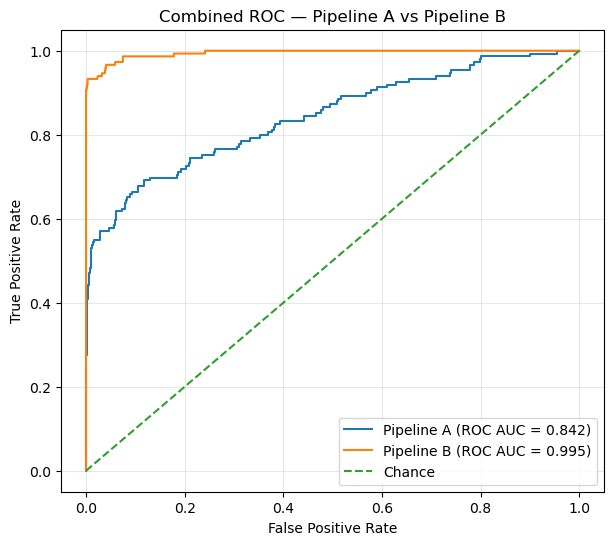

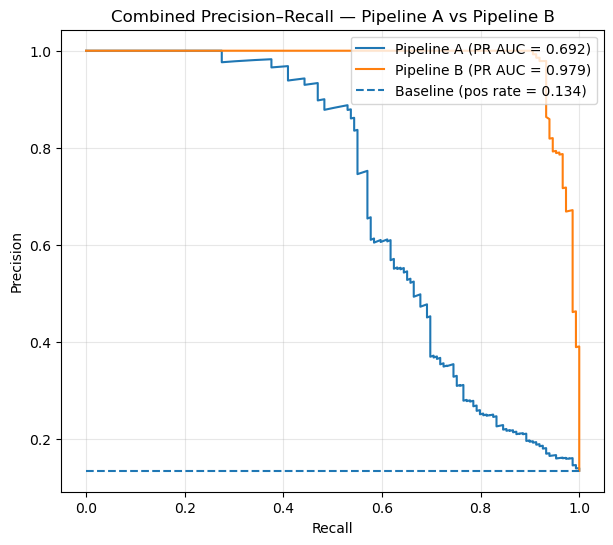

In [21]:
# ROC & PR plots for Pipeline A vs Pipeline B 


# Ensure we have probabilities for each pipeline
def _maybe_get_proba_A():
    
    try:
        return proba_A  # already computed
    except NameError:
        pass
    # Recompute if model & test features exist
    try:
        # nb: MultinomialNB trained on Xtr_A; Xte_A: test features (TF-IDF + ling)
        return nb.predict_proba(Xte_A)[:, 1]
    except Exception as e:
        raise RuntimeError("Could not obtain Pipeline A probabilities. "
                           "Make sure 'proba_A' exists or (nb, Xte_A) are in scope.") from e

def _maybe_get_proba_B():
    try:
        return proba_B  # already computed
    except NameError:
        pass
    # Recompute if model & test sequences exist
    try:
        # model: trained Keras model; Xte_pad: padded test sequences
        return model.predict(Xte_pad, verbose=0).reshape(-1)
    except Exception as e:
        raise RuntimeError("Could not obtain Pipeline B probabilities. "
                           "Make sure 'proba_B' exists or (model, Xte_pad) are in scope.") from e

pA = _maybe_get_proba_A()
pB = _maybe_get_proba_B()

# Basic sanity clamp (in case a decision_function got passed by mistake)
pA = np.clip(pA, 0, 1)
pB = np.clip(pB, 0, 1)

# Compute curves & AUCs

# ROC
fpr_A, tpr_A, _ = roc_curve(y_test, pA)
fpr_B, tpr_B, _ = roc_curve(y_test, pB)
roc_auc_A = auc(fpr_A, tpr_A)
roc_auc_B = auc(fpr_B, tpr_B)

# PR
prec_A, rec_A, _ = precision_recall_curve(y_test, pA)
prec_B, rec_B, _ = precision_recall_curve(y_test, pB)
ap_A = average_precision_score(y_test, pA)   # PR-AUC
ap_B = average_precision_score(y_test, pB)

pos_rate = (np.array(y_test) == 1).mean()   # baseline line in PR

# Plot Combined ROC 
plt.figure(figsize=(7,6))
plt.plot(fpr_A, tpr_A, label=f"Pipeline A (ROC AUC = {roc_auc_A:.3f})")
plt.plot(fpr_B, tpr_B, label=f"Pipeline B (ROC AUC = {roc_auc_B:.3f})")
plt.plot([0,1], [0,1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Combined ROC — Pipeline A vs Pipeline B")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

#Plot Combined Precision–Recall 
plt.figure(figsize=(7,6))
plt.plot(rec_A, prec_A, label=f"Pipeline A (PR AUC = {ap_A:.3f})")
plt.plot(rec_B, prec_B, label=f"Pipeline B (PR AUC = {ap_B:.3f})")
plt.hlines(pos_rate, xmin=0, xmax=1, linestyles="--", label=f"Baseline (pos rate = {pos_rate:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Combined Precision–Recall — Pipeline A vs Pipeline B")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()


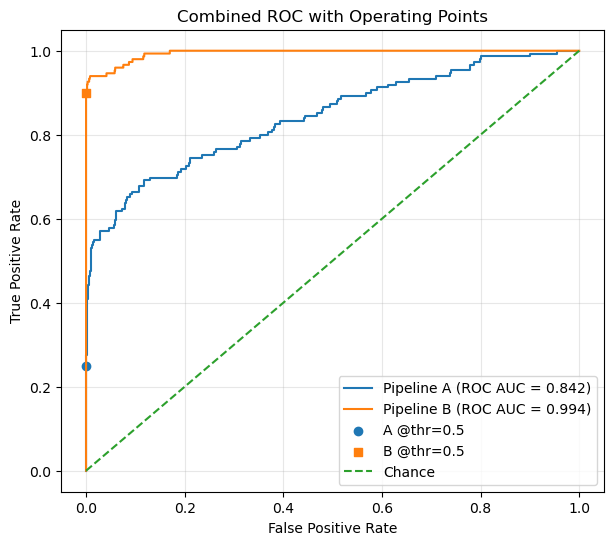

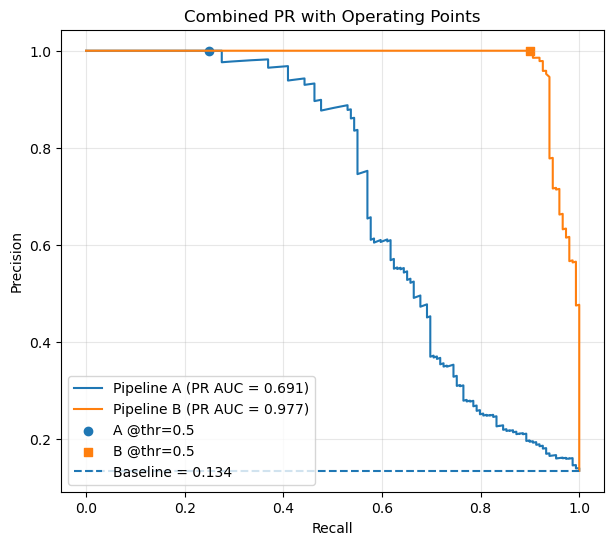

In [54]:
# show operating points on the curves with chosen threshold (0.5) on both plots

def point_for_threshold(y_true, probs, thr):
    # ROC point
    tp = ((probs >= thr) & (y_true == 1)).sum()
    fp = ((probs >= thr) & (y_true == 0)).sum()
    tn = ((probs <  thr) & (y_true == 0)).sum()
    fn = ((probs <  thr) & (y_true == 1)).sum()
    tpr = tp / (tp + fn + 1e-12)
    fpr = fp / (fp + tn + 1e-12)
    # PR point
    prec = tp / (tp + fp + 1e-12)
    rec  = tpr
    return fpr, tpr, rec, prec

thr = 0.50  # change to 0.30 or 0.70 to illustrate trade-offs
fprA, tprA, recA, precA = point_for_threshold(np.array(y_test), pA, thr)
fprB, tprB, recB, precB = point_for_threshold(np.array(y_test), pB, thr)

# After drawing each figure above, add:
# (Add to ROC)
plt.figure(figsize=(7,6))
plt.plot(fpr_A, tpr_A, label=f"Pipeline A (ROC AUC = {roc_auc_A:.3f})")
plt.plot(fpr_B, tpr_B, label=f"Pipeline B (ROC AUC = {roc_auc_B:.3f})")
plt.scatter([fprA], [tprA], marker="o", label=f"A @thr={thr}")
plt.scatter([fprB], [tprB], marker="s", label=f"B @thr={thr}")
plt.plot([0,1],[0,1],'--', label="Chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Combined ROC with Operating Points")
plt.legend(loc="lower right"); plt.grid(True, alpha=0.3); plt.show()

# (Add to PR)
plt.figure(figsize=(7,6))
plt.plot(rec_A, prec_A, label=f"Pipeline A (PR AUC = {ap_A:.3f})")
plt.plot(rec_B, prec_B, label=f"Pipeline B (PR AUC = {ap_B:.3f})")
plt.scatter([recA], [precA], marker="o", label=f"A @thr={thr}")
plt.scatter([recB], [precB], marker="s", label=f"B @thr={thr}")
plt.hlines(pos_rate, 0, 1, linestyles="--", label=f"Baseline = {pos_rate:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Combined PR with Operating Points")
plt.legend(loc="lower left"); plt.grid(True, alpha=0.3); plt.show()


**Feature Importance** — Pipeline A (Naïve Bayes)

We inspect top spam and top ham indicators using Naïve Bayes log-probability ratios over TF‑IDF features.

In [22]:
try:
    # NB keeps per-class log probabilities
    ratio = nb.feature_log_prob_[1] - nb.feature_log_prob_[0]
    # Recover TF-IDF vocabulary in index order
    vocab = np.array([t for t,_ in sorted(tfidf.vocabulary_.items(), key=lambda kv: kv[1])])
    tfidf_len = len(vocab)

    top_spam_idx = np.argsort(ratio[:tfidf_len])[-20:][::-1]
    top_ham_idx  = np.argsort(ratio[:tfidf_len])[:20]

    top_spam = pd.DataFrame({"Top Spam Terms": vocab[top_spam_idx], "LogProbRatio": np.round(ratio[:tfidf_len][top_spam_idx], 3)})
    top_ham  = pd.DataFrame({"Top Ham Terms":  vocab[top_ham_idx],  "LogProbRatio": np.round((-ratio[:tfidf_len])[top_ham_idx], 3)})

    display(top_spam)
    display(top_ham)
except Exception as e:
    print("Feature importance not available (ensure Pipeline A cells ran):", e)

,Top Spam Terms,LogProbRatio
0,call num,4.184
1,claim,3.692
2,to num,3.529
3,prize,3.488
4,num now,3.447
5,url,3.371
6,won,3.358
7,num cash,3.196
8,have won,3.165
9,to claim,3.091


,Top Ham Terms,LogProbRatio
0,my,2.472
1,ok,2.448
2,ill,2.430
3,ltgt,2.383
4,lor,2.154
5,later,2.150
6,but,2.127
7,im,2.120
8,da,2.095
9,come,2.069


**Consolidated Summary Table** for two pipelines (Accuracy, Precision, Recall, F1 and AUCs)

In [23]:
def pct(x): 
    try: return f"{x*100:.2f}%"
    except: return "—"

try:
    final = pd.DataFrame([
        evaluate_scores(y_test, sc, thr=0.5, label=name) for name, sc in pipeline_scores.items()
    ])
    # Pretty-format
    for col in ["Accuracy","Precision","Recall","F1"]:
        final[col] = final[col].apply(pct)
    final["ROC_AUC"] = final["ROC_AUC"].apply(lambda v: f"{v:.4f}" if pd.notnull(v) else "—")
    final["PR_AUC"]  = final["PR_AUC"].apply(lambda v: f"{v:.4f}" if pd.notnull(v) else "—")
    display(final[["Model","Accuracy","Precision","Recall","F1","ROC_AUC","PR_AUC","Threshold"]])
except Exception as e:
    print("Could not build summary table:", e)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Threshold
0,Pipeline A (TF-IDF+NB+Ling),89.96%,100.00%,24.83%,39.78%,—,0.6918,0.5
1,Pipeline B (Word2Vec→BiLSTM),98.74%,97.87%,92.62%,95.17%,—,0.9792,0.5


**Discussion:** Trade-offs, Challenges, and Takeaways

**Trade-offs:**  
- *Precision vs Recall*: Lowering the decision threshold (e.g., 0.30) generally **increases recall** (fewer missed spam) at the cost of **precision** (more false alarms). Raising it (e.g., 0.70) flips the trade-off. Choose based on business risk (missed spam vs blocked ham).  
- *Interpretability vs Capacity*: **Pipeline A** is highly interpretable and fast; **Pipeline B** (BiLSTM) has higher capacity to model sequence/semantics but is less transparent.

**Challenges observed:**  
- *Class imbalance*: SMS Spam Collection has relatively few spam messages. Prefer **F1** and **PR curves** over accuracy, and consider threshold tuning.  
- *Obfuscation*: Creative spelling and character substitutions can fool token-level features; sequence models help, as would char-level models.  
- *Compute*: Deep models need more time; apply **early stopping** and moderate sequence lengths.

**Key takeaways:**  
- A strong, production-friendly baseline is **TF‑IDF (1–2g) + NB + linguistic features**.  
- **Word2Vec→BiLSTM** often improves **recall** on tricky spam and is a good second pipeline to deploy when compute allows.  
- Calibrate thresholds to align with operational costs; consider a **quarantine band** for borderline scores.